In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
%reload_ext autoreload
import csv
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# open and parse .log file, after removing 15 header lines 
# each line after looks like: Epoch: [1/180000], mdis: 12222.005859375, the best: 12222.005859375, at 1.
log_file = "zod_20251211_093353.log"
data = []
with open(log_file, 'r') as f:
    for _ in range(15):
        next(f)  # skip header lines
    for line in f:
        parts = line.strip().split(',')
        try:
            epoch_part = int(parts[0].split('[')[1].split('/')[0])
            mdis_part = float(parts[1].split(': ')[1].strip())
            data.append((int(epoch_part), float(mdis_part)))
        except:
            continue
epochs, mdis_values = zip(*data)

FileNotFoundError: [Errno 2] No such file or directory: 'zod_20251211_093353.log'

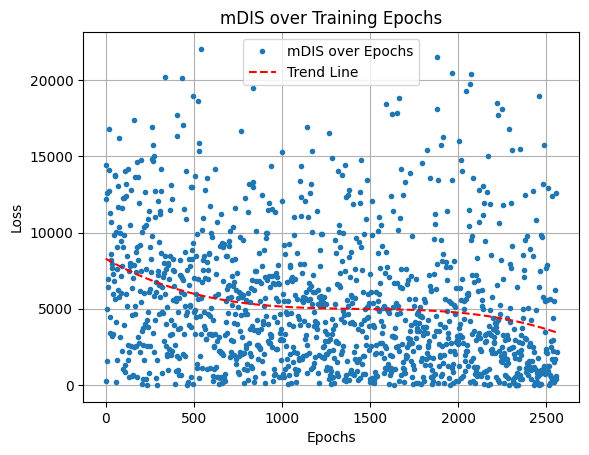

In [ ]:
# plt.plot(epochs, mdis_values,label='Loss')
plt.plot(epochs, mdis_values,".",label='mDIS over Epochs')
# fit a trend line
z = np.polyfit(epochs, mdis_values,3)
p = np.poly1d(z)
plt.plot(epochs, p(epochs), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('mDIS over Training Epochs')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# open and parse .log file, after removing 15 header lines 
# each line after looks like: Epoch: [1/180000], mdis: 12222.005859375, the best: 12222.005859375, at 1.
log_file = "logs/log_2746423.log"
loss_list = []
RTE_l2_list = []
with open(log_file, 'r') as f:
    for _ in range(10):
        next(f)  # skip header lines
    for line in f:
        parts = line.strip().split(',')
        try:
            # epoch_part = int(parts[0].split('[')[1].split('/')[0])
            loss = float(parts[1].split(': ')[1].strip())
            RTE_l2 = float(parts[2].split(': ')[1].strip())
            # print(loss)
            loss_list.append(loss)
            RTE_l2_list.append(RTE_l2)
        except:
            continue

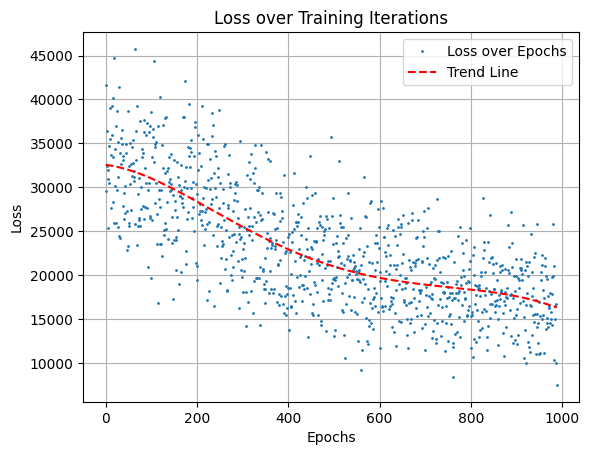

In [ ]:
plt.plot(loss_list,".", markersize=2,label='Loss over Epochs')
it = list(range(len(loss_list)))
z = np.polyfit(it, loss_list,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

In [ ]:
loss_list[:5]

[]

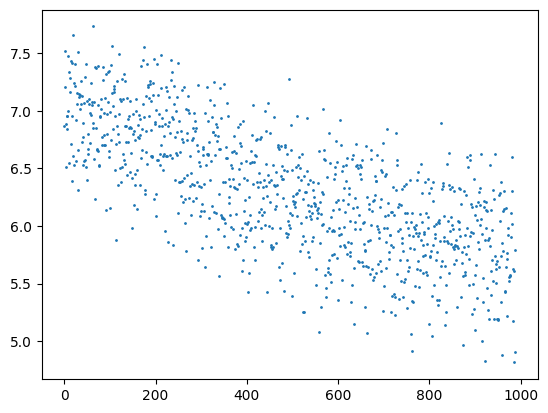

In [ ]:
plt.plot(RTE_l2_list,".", markersize=2,label='Loss over Epochs')
z = np.polyfit(it, RTE_l2_list,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

In [ ]:
RTE_l2_list2 = np.sqrt(RTE_l2_list)
print(RTE_l2_list2[-100:].mean())
plt.plot(RTE_l2_list2,".", markersize=2,label='Loss over Epochs')

z = np.polyfit(it, RTE_l2_list2,5)
p = np.poly1d(z)
plt.plot(it, p(it), "r--", label='Trend Line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Training Iterations')
plt.legend()
plt.grid()
plt.show()

NameError: name 'RTE_l2_list' is not defined

# 1st real training

In [ ]:
fp ="metrics/train/2025_12_12_0.csv"

df = pd.read_csv(fp)
df.head()

,epoch,batch,loss,rte
0,0,0,24971.986328,45.308849
1,0,1,46214.289062,58.956730
2,0,2,32598.015625,49.203766
3,0,3,24418.972656,38.694992
4,0,4,19000.382812,38.162357


In [ ]:
df.loss[-500:].mean()

60.45634482383728

Text(0.5, 0, 'Iterations')

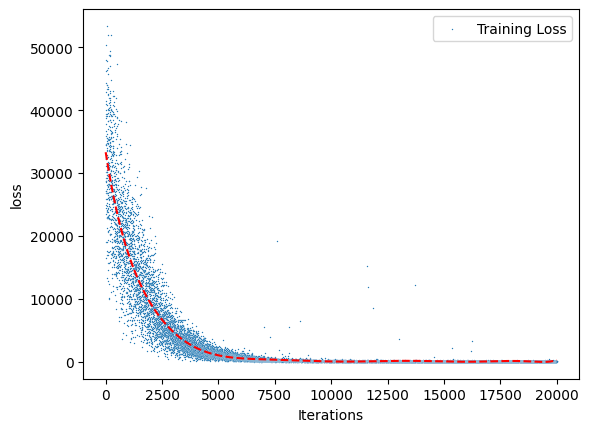

In [ ]:
sns.scatterplot(data=df, x=df.index, y='loss', label='Training Loss', s=1)
# trend line
z = np.polyfit(df.index, df['loss'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')

Final 1000 mean L2 : 2.24


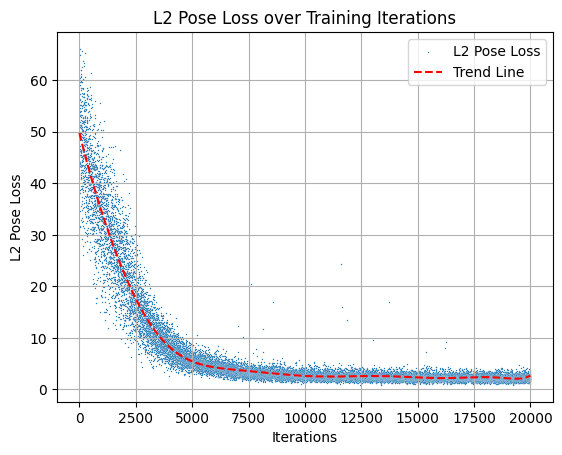

In [ ]:
sns.scatterplot(data=df, x=df.index, y='rte', label='L2 Pose Loss', s=1)
# trend line
z = np.polyfit(df.index, df['rte'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('L2 Pose Loss')
plt.title('L2 Pose Loss over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean L2 : {df.rte[-1000:].mean():.2f}")


In [ ]:
df.rte[-500:].mean()

2.2686761453151703

In [ ]:
np.sqrt(2.268)

1.5059880477613359

# 2nd training

In [18]:
fp  = "metrics/train/2025_12_20_1.csv"
df = pd.read_csv(fp)
df.head()

,epoch,batch,loss,loss_h,loss_c,trans_l2_m,yaw_err_deg
0,0,0,4108.822754,40922.570312,16.565622,11.806542,9.749927
1,0,1,5179.209961,51540.679688,25.142090,14.195226,12.044998
2,0,2,3549.908691,35226.621094,27.246534,9.206993,14.758420
3,0,3,3485.656250,34504.968750,35.159363,10.648845,10.179621
4,0,4,2686.461670,26640.640625,22.397398,9.519965,4.409631


Final 1000 mean loss : 343.6969


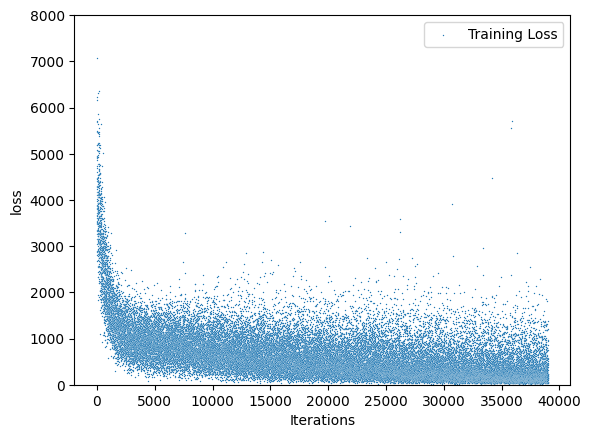

In [25]:
sns.scatterplot(data=df, x=df.index, y='loss', label='Training Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='loss', label='Training Loss')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
# z = np.polyfit(df.index, df['loss'], 20)
# p = np.poly1d(z)
# plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0, 8000)
# print average loss over last 1000 iterations
print(f"Final 1000 mean loss : {df.loss[-1000:].mean():.4f}")

(0.0, 50.0)

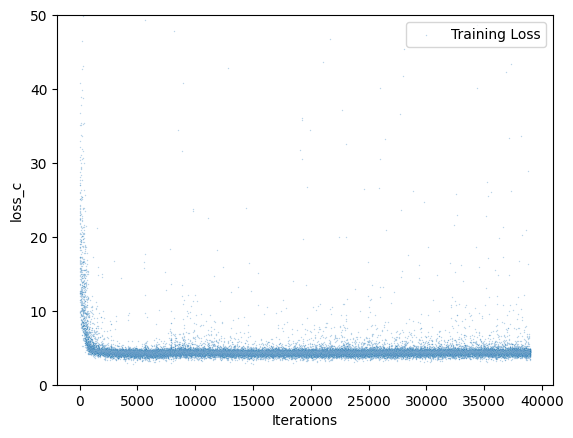

In [35]:
sns.scatterplot(data=df, x=df.index, y='loss_c', label='Training Loss', s=1, alpha=0.3)
# sns.lineplot(data=df, x=df.index, y='loss_c', label='Loss C')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
# z = np.polyfit(df.index, df['loss_c'], 15)
# p = np.poly1d(z)
# plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0, 50)

/tmp/ipykernel_3757012/3663579962.py:8: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df['loss_h'], 20)


(0.0, 62000.0)

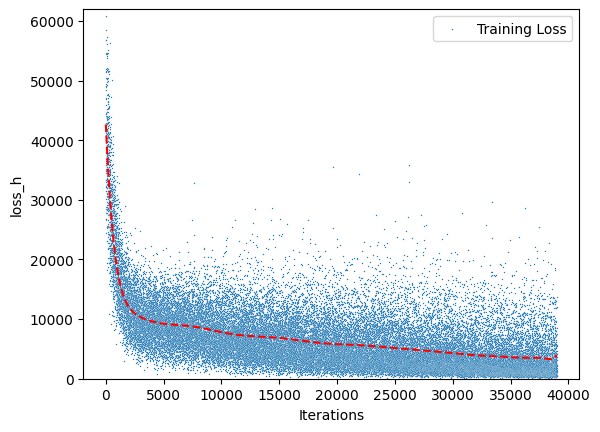

In [38]:
sns.scatterplot(data=df, x=df.index, y='loss_h', label='Training Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='loss_h', label='Loss H')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
z = np.polyfit(df.index, df['loss_h'], 20)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0,62000)

Final 1000 mean L2 : 0.63


(0.0, 16.0)

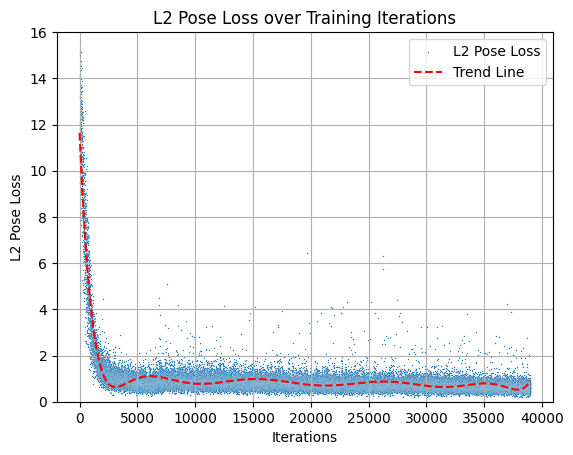

In [39]:
sns.scatterplot(data=df, x=df.index, y='trans_l2_m', label='L2 Pose Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='trans_l2_m', label='Lk2 Pose Loss')
# trend line
z = np.polyfit(df.index, df['trans_l2_m'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('L2 Pose Loss')
plt.title('L2 Pose Loss over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean L2 : {df.trans_l2_m[-500:].mean():.2f}")
plt.ylim(0,16)


Final 1000 mean Yaw Error : 4.93


(0.0, 18.0)

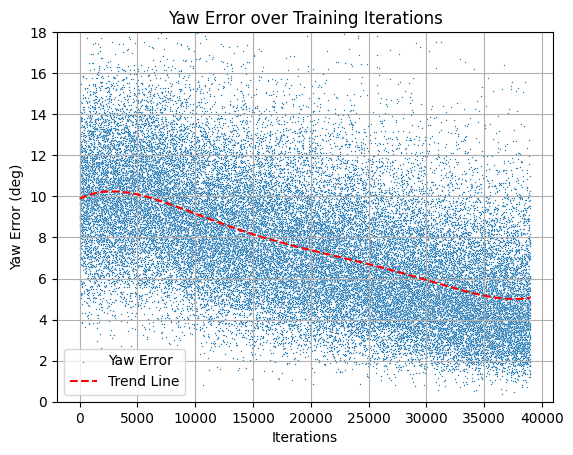

In [40]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error', s=1)
# sns.lineplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error')
# trend line
z = np.polyfit(df.index, df['yaw_err_deg'],5)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('Yaw Error (deg)')
plt.title('Yaw Error over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean Yaw Error : {df.yaw_err_deg[-1000:].mean():.2f}")
plt.ylim(0,18)


In [3]:
# define plotting function for loss, loss_h, loss_c, l2 pose loss, yaw error in one plot
def plot_metric(df, title):
    
    metric = ["loss", "loss_h", "loss_c", "trans_l2_m", "yaw_err_deg"]
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    
    for m in metric:
        last_mean = df[m][-500:].mean()
        sns.scatterplot(data=df, x=df.index, y=m, label="Final Mean: {:.4f}".format(last_mean), s=1, ax=ax.flatten()[metric.index(m)])
        # trend line
        z = np.polyfit(df.index, df[m],15)
        p = np.poly1d(z)
        ax.flatten()[metric.index(m)].plot(df.index, p(df.index), "r--", label='Trend Line')
        ax.flatten()[metric.index(m)].set_xlabel('Iterations')
        ax.flatten()[metric.index(m)].set_ylim([0, df[m][0:10].max()*1.1])
        ax.flatten()[metric.index(m)].set_ylabel(m)
        ax.flatten()[metric.index(m)].set_title(m+' over Training Iterations')
        ax.flatten()[metric.index(m)].legend()
        ax.flatten()[metric.index(m)].grid()
    fig.suptitle(title)
    fig.tight_layout()
    fig.show()

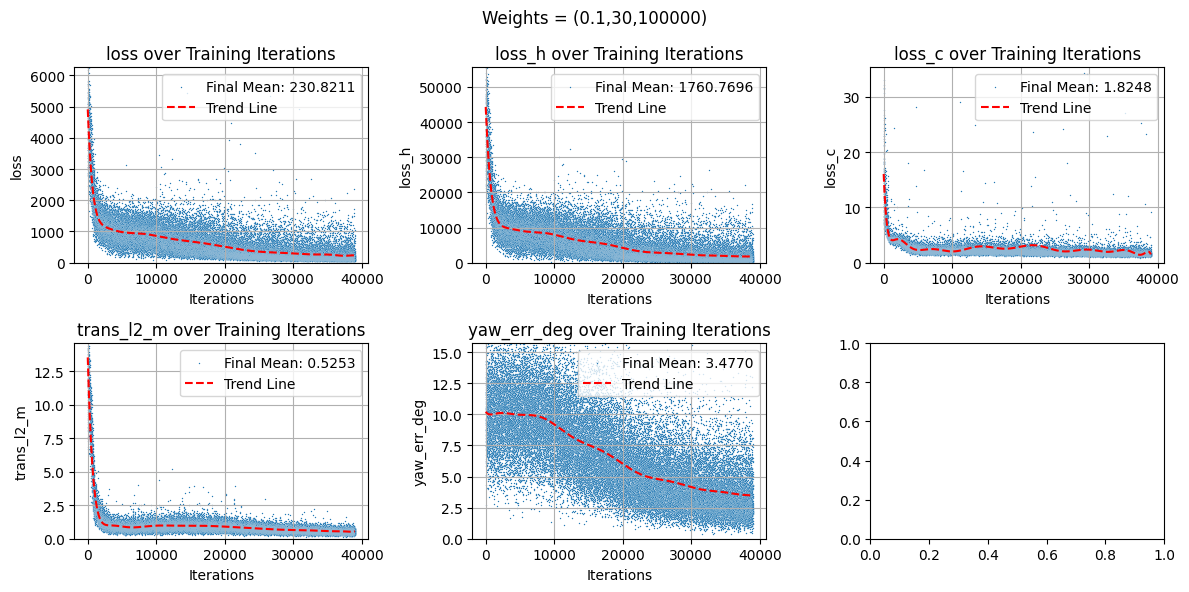

In [62]:
fp  = "metrics/train/2025_12_20_0.csv"
df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,30,100000)')

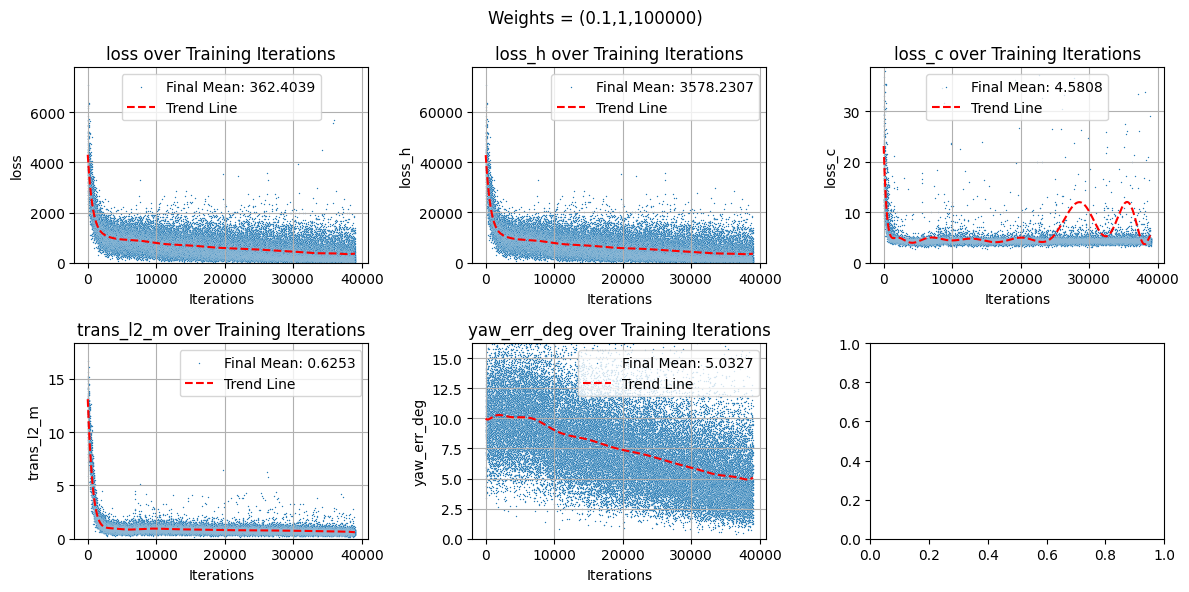

In [63]:
fp  = "metrics/train/2025_12_20_1.csv"
df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,1,100000)')

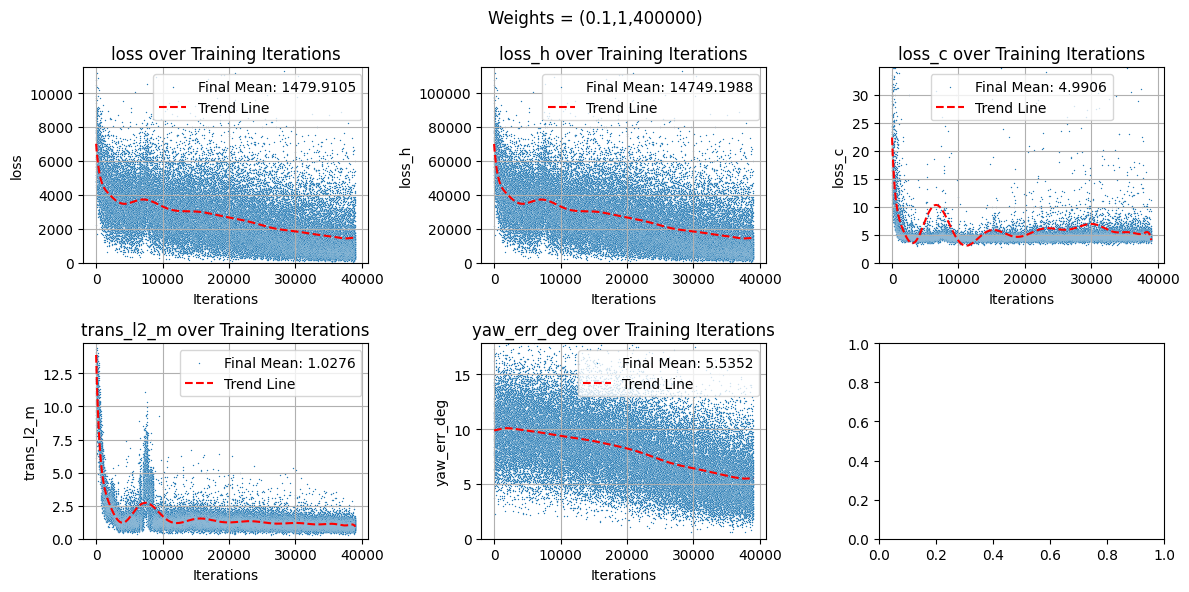

In [64]:
fp  = "metrics/train/2025_12_20_2.csv"
df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,1,400000)')

/tmp/ipykernel_936286/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_936286/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_936286/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_936286/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_936286/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)


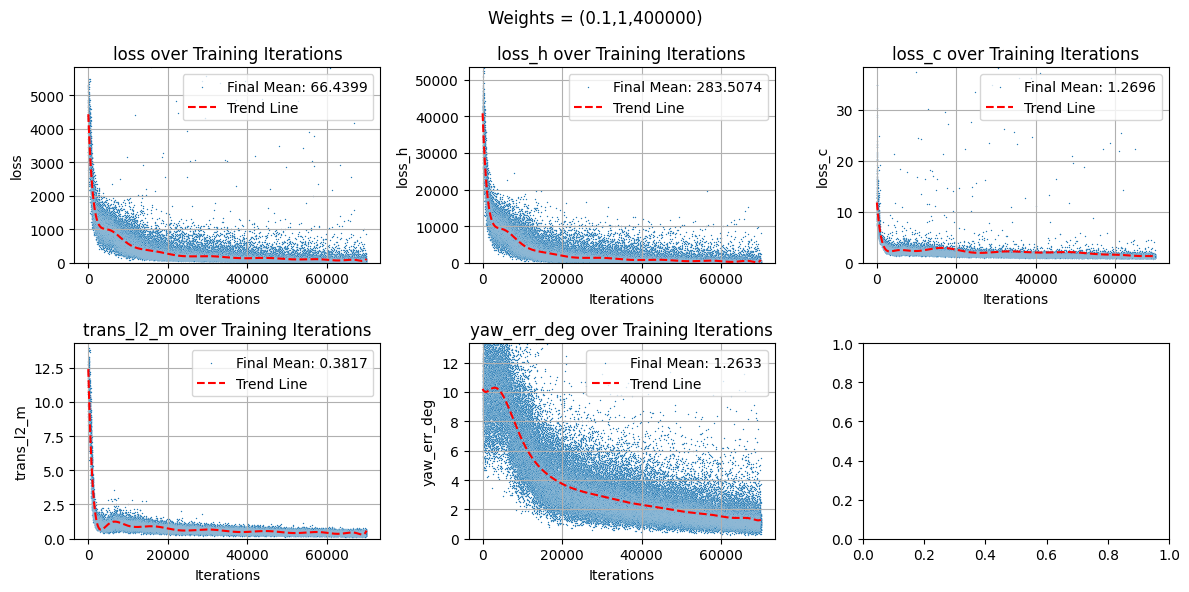

In [4]:
fp = "metrics/train/2025_12_21_2.csv"

df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,1,400000)')

In [6]:
# print mean values of last 500 iterations
for col in df.columns:
    print(f"{col}: {df[col][-500:].mean():.3f}")

epoch: 11.000
batch: 4564.500
loss: 66.440
loss_h: 283.507
loss_c: 1.270
trans_l2_m: 0.382
yaw_err_deg: 1.263


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
fp  = "metrics/val/2025_12_26_2.csv"
df = pd.read_csv(fp)


In [5]:
df.loc[df.meters_l2 > 1.5]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
509,"[17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]","[2311, 2312, 2313, 2314, 2315, 2316, 2317, 231...",509,1.514854,0.267418,622.012138


In [6]:
df.iloc[df.meters_l2.argmax()]

scene_name      [17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]
frame_name     [2311, 2312, 2313, 2314, 2315, 2316, 2317, 231...
iteration                                                    509
meters_l2                                               1.514854
yaw_err_deg                                             0.267418
time_ms                                               622.012138
Name: 509, dtype: object

In [7]:
df.iloc[df.yaw_err_deg.argmax()]

scene_name                  [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
frame_name     [336, 337, 338, 339, 340, 341, 342, 343, 344, ...
iteration                                                    538
meters_l2                                               0.273455
yaw_err_deg                                            35.750263
time_ms                                               484.557867
Name: 538, dtype: object

In [8]:
df

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0,0.062411,1.477947,13801.431894
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]",1,0.529389,0.305976,387.307167
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]",2,0.311225,0.400995,362.158298
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]",3,0.039256,0.484542,461.096048
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]",4,0.223919,1.821548,501.677036
...,...,...,...,...,...,...
862,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[1931, 1932, 1933, 1934, 1935, 1936, 1937, 193...",862,0.156637,3.644201,193.126440
863,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[1943, 1944, 1945, 1946, 1947, 1948, 1949, 195...",863,0.229632,1.960808,192.905664
864,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[1955, 1956, 1957, 1958, 1959, 1960, 1961, 196...",864,0.058972,2.296771,193.532944
865,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","[1967, 1968, 1969, 1970, 1971, 1972, 1973, 197...",865,0.077830,0.152024,194.320679


<Axes: xlabel='None', ylabel='meters_l2'>

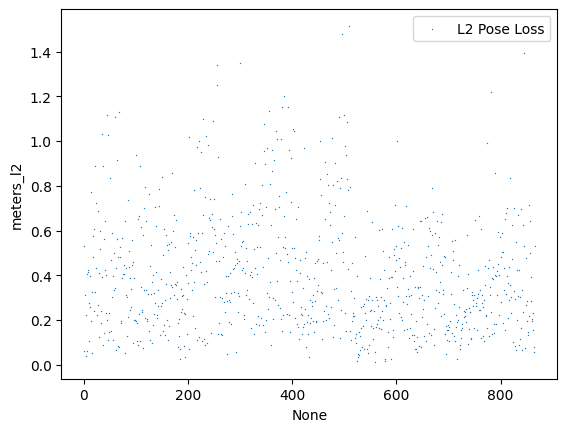

In [10]:
import seaborn as sns
sns.scatterplot(data=df, x=df.index, y='meters_l2', label='L2 Pose Loss', s=1)

<Axes: xlabel='None', ylabel='yaw_err_deg'>

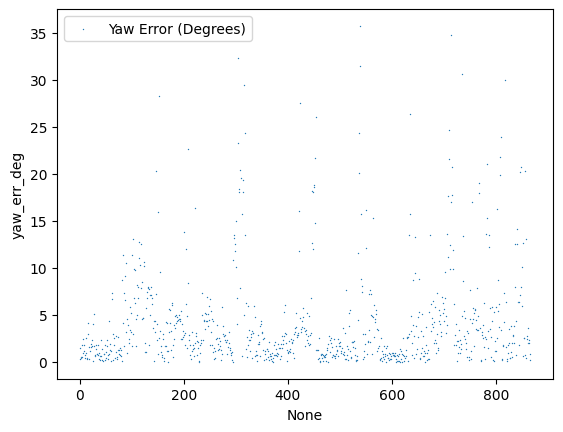

In [11]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error (Degrees)', s=1)